In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np 
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import regionmask

ERROR 1: PROJ: proj_create_from_database: Open of /opt/sw/anaconda3/2023.09/envs/pangeo23/share/proj failed


In [3]:
url = "https://www2.census.gov/geo/tiger/GENZ2022/shp/cb_2022_us_state_20m.zip"
states = gpd.read_file(url)
states.head()

,STATEFP,STATENS,AFFGEOID,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
0,48,01779801,0400000US48,48,TX,Texas,00,676685555821,18974391187,"POLYGON ((-106.62345 31.91403, -106.63011 31.9..."
1,06,01779778,0400000US06,06,CA,California,00,403673617862,20291712025,"MULTIPOLYGON (((-118.59397 33.46720, -118.4847..."
2,21,01779786,0400000US21,21,KY,Kentucky,00,102266581101,2384240769,"POLYGON ((-89.54443 36.57451, -89.47935 36.566..."
3,13,01705317,0400000US13,13,GA,Georgia,00,149486268417,4418716153,"POLYGON ((-85.60516 34.98468, -85.47434 34.983..."
4,55,01779806,0400000US55,55,WI,Wisconsin,00,140292518676,29343193162,"MULTIPOLYGON (((-86.93428 45.42115, -86.83575 ..."


Text(116.97222222222221, 0.5, 'latitude')

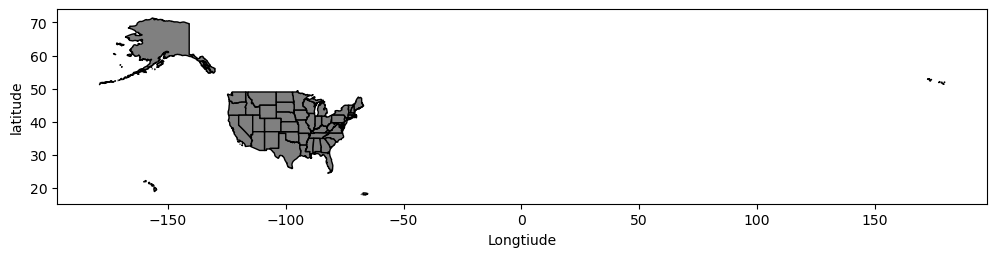

In [4]:
fig, ax = plt.subplots(figsize=(12,6))
states.plot(ax=ax, edgecolor='black', facecolor='grey')
ax.set_xlabel('Longtiude')
ax.set_ylabel('latitude')

Text(153.3409704748165, 0.5, 'latitude')

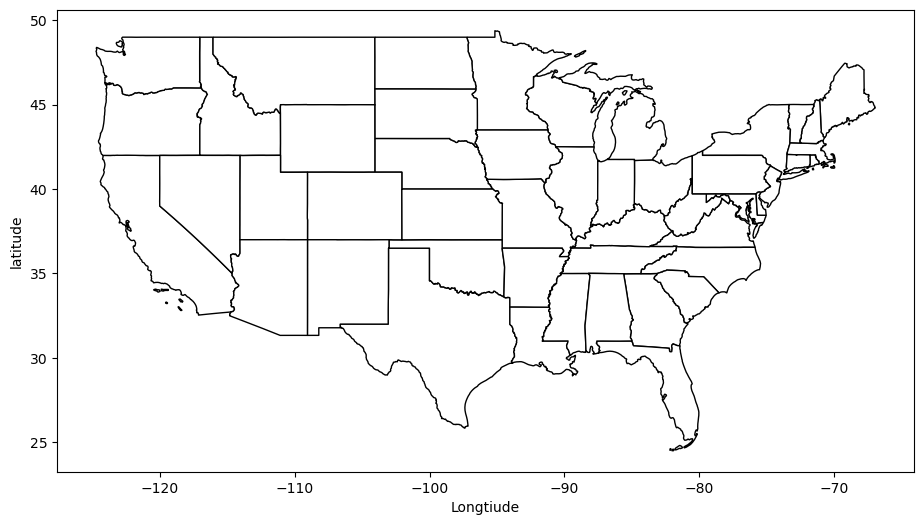

In [7]:
exclude = ['AK', 'HI', 'PR', 'AS', 'GU', 'MP', 'VI']
conus = states[~states['STUSPS'].isin(exclude
                    )].copy().reset_index(drop=True)
fig, ax = plt.subplots(figsize=(12,6))
conus.plot(ax=ax, edgecolor='black', facecolor='white')
ax.set_xlabel('Longtiude')
ax.set_ylabel('latitude')

In [8]:
print(states.crs)

EPSG:4269


In [10]:
conus = conus.to_crs('EPSG:4326')
print(conus.crs)

EPSG:4326


In [11]:
conus.geometry.area

/tmp/ipykernel_521612/1217723325.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  conus.geometry.area


0     65.778595
1     41.730153
2     10.665631
3     14.682547
4     16.512930
5     28.183009
6     18.603966
7     10.776528
8     10.892137
9     11.856402
10    14.073650
11    24.484618
12    14.227633
13    15.413224
14    45.053080
15    25.566646
16     2.865091
17    15.848949
18     0.018580
19    11.332121
20    21.617188
21    21.304866
22    22.577977
23    17.996637
24    27.973602
25     6.513444
26     9.880174
27     2.392569
28    29.937267
29    21.841993
30    13.591404
31    11.866931
32    28.036515
33    13.567503
34    22.977375
35    30.892801
36    22.013618
37     0.346347
38    17.352434
39     0.553716
40    12.897365
41     7.861240
42    10.002766
43     2.134602
44    12.537439
45     2.683523
46    28.921290
47     1.400262
48     2.801607
dtype: float64

In [13]:
conus['area_km'] = conus.to_crs('EPSG:5070').geometry.area / 1e6
conus[['NAME', 'area_km']].sort_values('area_km')

,NAME,area_km
18,District of Columbia,178.935337
37,Rhode Island,3203.881030
39,Delaware,5324.651992
47,Connecticut,12961.947245
43,New Jersey,20184.523415
27,Massachusetts,21937.654739
45,New Hampshire,24038.175920
48,Vermont,24935.186182
16,Maryland,27542.444201
25,West Virginia,62943.349776


In [14]:
conus['centroid'] = conus.geometry.centroid
conus[['NAME','centroid']]

/tmp/ipykernel_521612/1221123100.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  conus['centroid'] = conus.geometry.centroid


,NAME,centroid
0,Texas,POINT (-99.33232 31.46200)
1,California,POINT (-119.61112 37.24221)
2,Kentucky,POINT (-85.28902 37.52595)
3,Georgia,POINT (-83.44336 32.64809)
4,Wisconsin,POINT (-90.00945 44.63903)
5,Oregon,POINT (-120.55674 43.93693)
6,Missouri,POINT (-92.47789 38.36847)
7,Virginia,POINT (-78.78781 37.51260)
8,Tennessee,POINT (-86.34064 35.84332)
9,Louisiana,POINT (-91.94549 31.02018)


Text(153.3409704748165, 0.5, 'latitude')

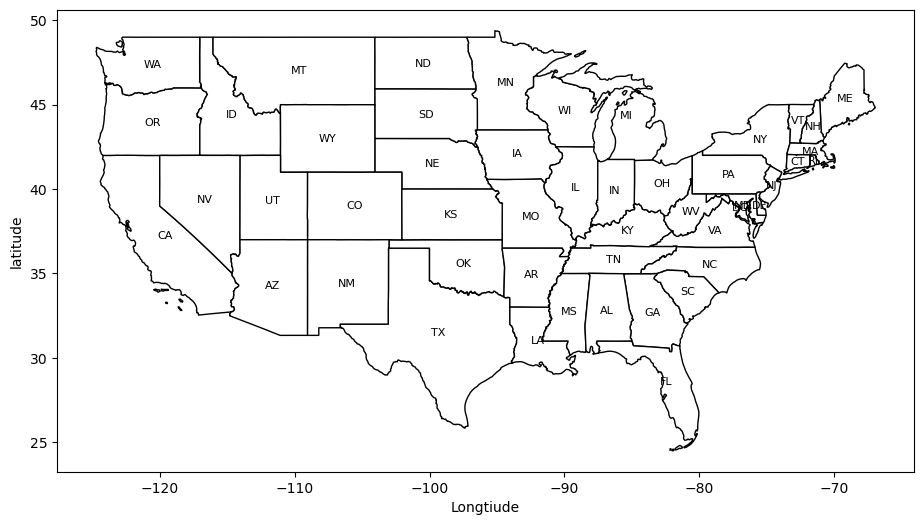

In [15]:
fig, ax = plt.subplots(figsize=(12,6))
conus.plot(ax=ax, edgecolor='black', facecolor='white')

for _, state in conus.iterrows(): 
    ax.annotate(state['STUSPS'], xy=(state['centroid'].x, 
                                     state['centroid'].y),
                ha='center', va='center', fontsize=8)


ax.set_xlabel('Longtiude')
ax.set_ylabel('latitude')

Text(153.3409704748165, 0.5, 'latitude')

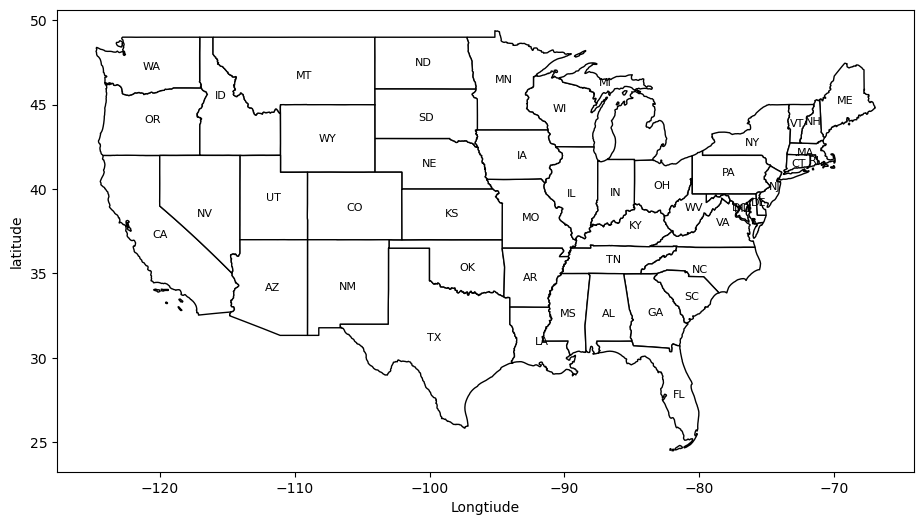

In [16]:
fig, ax = plt.subplots(figsize=(12,6))
conus.plot(ax=ax, edgecolor='black', facecolor='white')

conus['label_point'] = conus.geometry.representative_point()

for _, state in conus.iterrows(): 
    ax.annotate(state['STUSPS'], xy=(state['label_point'].x, 
                                     state['label_point'].y),
                ha='center', va='center', fontsize=8)


ax.set_xlabel('Longtiude')
ax.set_ylabel('latitude')

In [18]:
air_ds = xr.tutorial.load_dataset('air_temperature')
air_ds

<xarray.Dataset> Size: 31MB
Dimensions:  (lat: 25, time: 2920, lon: 53)
Coordinates:
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
Data variables:
    air      (time, lat, lon) float64 31MB 241.2 242.5 243.5 ... 296.2 295.7
Attributes:
    Conventions:  COARDS
    title:        4x daily NMC reanalysis (1948)
    description:  Data is from NMC initialized reanalysis\n(4x/day).  These a...
    platform:     Model
    references:   http://www.esrl.noaa.gov/psd/data/gridded/data.ncep.reanaly...

In [19]:
air_ds = xr.tutorial.load_dataset('air_temperature')
air_ds = air_ds.assign_coords(lon=(((air_ds.lon + 180
                                    ) % 360) - 180)).sortby('lon')
air_mean = air_ds.air.mean('time')
air_mean

<xarray.DataArray 'air' (lat: 25, lon: 53)> Size: 11kB
array([[260.37644178, 260.18305137, 259.88662671, ..., 250.81590068,
        251.93811644, 253.43804795],
       [262.73439384, 262.79397603, 262.74933904, ..., 249.75590411,
        251.58575685, 254.35926027],
       [264.7687637 , 264.32730822, 264.06169521, ..., 250.60789041,
        253.58351027, 257.71559932],
       ...,
       [297.64986301, 296.95333219, 296.62931507, ..., 296.81092466,
        296.28796233, 295.81645548],
       [298.12920205, 297.93700685, 297.47039384, ..., 296.85954795,
        296.7770274 , 296.44383562],
       [298.36615068, 298.38573973, 298.11414384, ..., 297.33820548,
        297.28144521, 297.30510274]])
Coordinates:
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B -160.0 -157.5 -155.0 ... -35.0 -32.5 -30.0

In [21]:
mask = regionmask.mask_3D_geopandas(
    conus,
    air_mean.lon, 
    air_mean.lat)

mask

<xarray.DataArray 'mask' (region: 42, lat: 25, lon: 53)> Size: 56kB
array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
...
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]]])
Coordinates:
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B -160.0 -157.5 -155.0 ... -35.0 -32.5 -30.0
  * region   (region) int64 336B 0 1 2 3 4 5 6 7 8 ... 38 40 41 42 43 44 46 48
Attributes:
    standard_name:  region

In [24]:
weights = np.cos(np.deg2rad(air_mean.lat))
state_means = air_mean.weighted(weights*mask).mean(['lat','lon'])

conus['mean_temp_C'] = np.nan
conus.loc[state_means.region.values,
    'mean_temp_C'] = state_means.values - 273.15
conus[['NAME', 'mean_temp_C']]

,NAME,mean_temp_C
0,Texas,18.596559
1,California,14.665964
2,Kentucky,12.113733
3,Georgia,16.934575
4,Wisconsin,5.398594
5,Oregon,8.719707
6,Missouri,11.821582
7,Virginia,11.996904
8,Tennessee,14.333454
9,Louisiana,19.113672


Text(0.5, 1.0, 'NCEP Mean Annual Temperature by State')

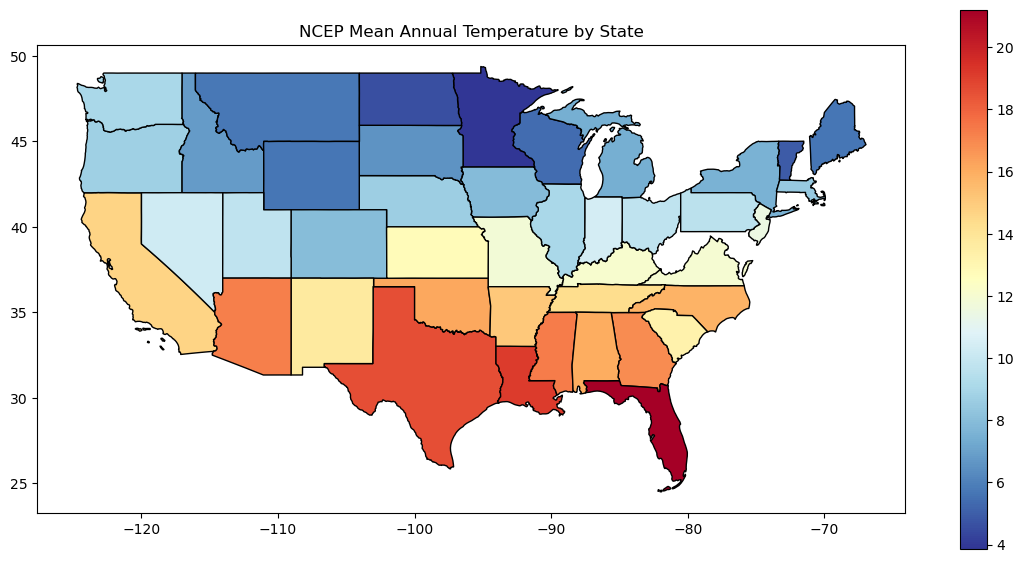

In [27]:
fig, ax = plt.subplots(figsize=(14,7))
conus.plot(ax=ax, column='mean_temp_C', 
           cmap='RdYlBu_r', 
           edgecolor='k', 
          legend=True
          ) 
ax.set_title('NCEP Mean Annual Temperature by State')